In [13]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

amazon = "amazon_tv_data.csv"
ebay = "ebay_tv.csv"
target = "target_tv_data_clean.csv"
walmart = "walmart_tvs.csv"

df_amazon = pd.read_csv(amazon)
df_ebay = pd.read_csv(ebay)
df_target = pd.read_csv(target)
df_walmart = pd.read_csv(walmart)

df_amazon['store'] = 'Amazon'
df_ebay['store'] = 'eBay'
df_target['store'] = 'Target'
df_walmart['store'] = 'Walmart'


df = pd.concat([df_amazon, df_ebay, df_target, df_walmart], ignore_index=True)

df['screen_size_inch'] = pd.to_numeric(df['screen_size_inch'], errors='coerce')

df['price'] = df['price'].astype(str).str.replace(r'[^0-9.]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df_clean = df.dropna(subset=['price', 'screen_size_inch'])


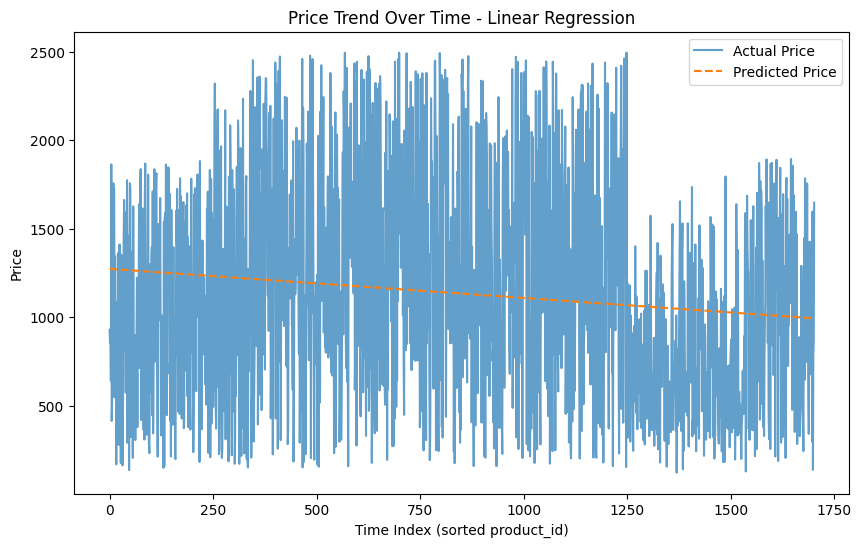

In [14]:
df_clean['product_id'] = df_clean['product_id'].astype(str)
df_sorted = df_clean.sort_values('product_id')
df_sorted['time_index'] = np.arange(len(df_sorted))

df_sorted = df_clean.sort_values('product_id')
df_sorted['time_index'] = np.arange(len(df_sorted))


X_lr = df_sorted[['time_index']]
y_lr = df_sorted['price']

model = LinearRegression()
model.fit(X_lr, y_lr)

df_sorted['predicted_price'] = model.predict(X_lr)

plt.figure(figsize=(10,6))
plt.plot(df_sorted['time_index'], df_sorted['price'], label='Actual Price', alpha=0.7)
plt.plot(df_sorted['time_index'], df_sorted['predicted_price'], label='Predicted Price', linestyle='--')
plt.xlabel('Time Index (sorted product_id)')
plt.ylabel('Price')
plt.title('Price Trend Over Time - Linear Regression')
plt.legend()
plt.show()

df_clean.to_csv('combined_tv_data_with_clusters.csv', index=False)

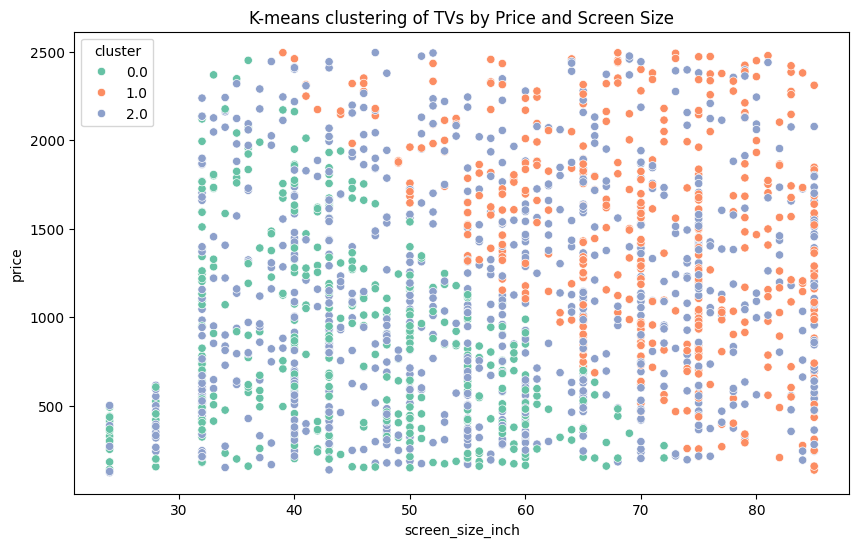

In [16]:
df_ml = df_clean.copy()

df_ml['smart_feature_num'] = df_ml['smart_feature'].map({'Yes':1, 'No':0}).fillna(0)

X = df_ml[['price', 'screen_size_inch', 'smart_feature_num']].dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df_ml.loc[X.index, 'cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_ml, x='screen_size_inch', y='price', hue='cluster', palette='Set2')
plt.title('K-means clustering of TVs by Price and Screen Size')
plt.show()

#0 - small price, small screen size, often without smart TV
#1 - medium price, medium screen size, usually with smart TV
#2 - high price, big screen size, almost all models with smart TV


              precision    recall  f1-score   support

           0       0.49      0.50      0.49       167
           1       0.51      0.50      0.50       174

    accuracy                           0.50       341
   macro avg       0.50      0.50      0.50       341
weighted avg       0.50      0.50      0.50       341



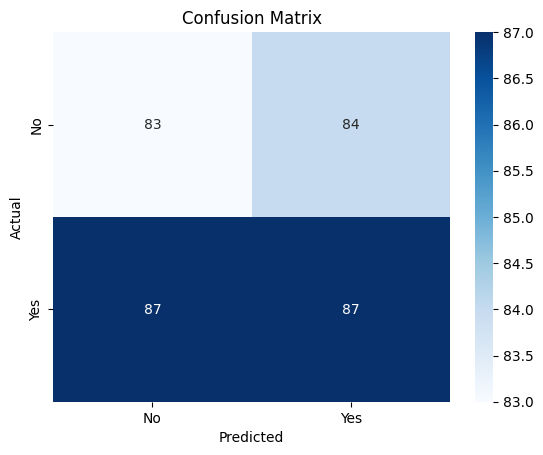

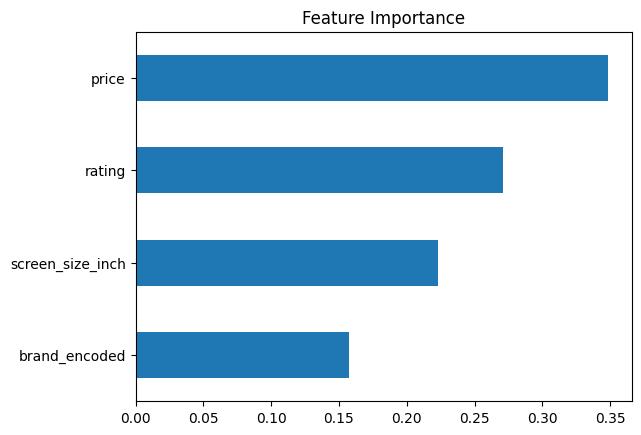

In [18]:
#whether a TV is a Smart TV (Yes/No) based on other features

df['Smart_TV_binary'] = df['smart_feature'].map({'Yes': 1, 'No': 0})

df_clean = df.dropna(subset=['Smart_TV_binary', 'price', 'product_brand', 'screen_size_inch', 'rating'])

le_brand = LabelEncoder()
df_clean['brand_encoded'] = le_brand.fit_transform(df_clean['product_brand'])

X = df_clean[['price', 'brand_encoded', 'screen_size_inch', 'rating']]
y = df_clean['Smart_TV_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

feat_imp = pd.Series(clf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()
